<a href="https://colab.research.google.com/github/Huang-stat/Computer-Labs/blob/main/AKHU_CS_Lab2_ABC_Decorators_AI_Model_0504.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AKHU CS Lab 2 - Abstract Base Classes and Robust AI Model Logging

**Topic:** `BaseModel`, `fit/predict`, `@log_execution`, data validation, and beginner model interpretation  
**Lecture:** about 35 minutes  
**Practice:** about 30 minutes


**Five-mode explanation pattern used in this notebook:**

| Mode | Learner question |
|---|---|
| Math mode | What is the formula or structure? |
| Statistics equations | What quantity is measured or estimated? |
| Interpretation | What does the result mean in plain language? |
| Remarks | What mistakes or limitations should we notice? |
| Python code | How do we implement it? |

## 0. Setup and data

The notebook is self-contained. It writes four small CSV files into a local `data/` folder if they are missing.

Main dataset: `AKHU_learner_scores_lab2.csv`  
Optional datasets for demonstrations and group work:

- `AKHU_sleep_screen_focus_lab2.csv`
- `AKHU_campus_energy_lab2.csv`
- `AKHU_ai_chatbot_logs_lab2.csv`

## 0A. Useful Python packages and functions

Use this table as a map. The package is the toolbox, the function or class is the tool, and the purpose explains why we use it.

| Package | Useful functions/classes | Purpose in this lab |
|---|---|---|
| `pathlib` | `Path()`, `exists()` | Build file paths for local folders, Colab uploads, and the `data/` folder. |
| `pandas` | `read_csv()`, `head()`, `agg()`, `corr()`, `isna()`, `isnull()`, `info()` | Load the CSV file, inspect rows, compute statistics, compute correlation, and check missing values. |
| `numpy` | `array()`, `ones()`, `column_stack()`, `@`, `linalg.pinv()` | Store numerical data, build the design matrix, multiply matrices, and compute coefficients. |
| `abc` | `ABC`, `@abstractmethod` | Define the `BaseModel` contract requiring `fit` and `predict`. |
| `matplotlib` | `pyplot.subplots()`, `hist()`, `scatter()`, `bar()`, `plot()` | Draw histograms, scatter plots, residual plots, and model-comparison charts. |
| `functools` | `wraps()` | Build a decorator while preserving the original method name and metadata. |
| `logging` | `basicConfig()`, `getLogger()`, `info()`, `error()` | Record when `fit` or `predict` starts, ends, succeeds, or fails. |
| `time` | `perf_counter()` | Measure how long a method takes to run. |
| `scikit-learn` | `LinearRegression()`, `mean_absolute_error()`, `mean_squared_error()`, `r2_score()` | Optional package check for regression and evaluation after formulas are understood. |

**Interaction:** choose one row. One learner names the package and one function; the other learner explains the purpose in one sentence.


### Code-supported hint: `abc` module
`ABC` and `@abstractmethod` are defined in Python's built-in `abc` module. The example below uses a simple `Shape` contract before we build the AI-style `BaseModel` contract.

In [1]:
from abc import ABC, abstractmethod

class Shape(ABC):
    @abstractmethod
    def area(self):
        pass

    @abstractmethod
    def perimeter(self):
        pass

class Rectangle(Shape):
    def __init__(self, width, height):
        self.width = width
        self.height = height

    def area(self):
        return self.width * self.height

    def perimeter(self):
        return 2 * (self.width + self.height)

rect = Rectangle(5, 10)
print("Area:", rect.area())
print("Perimeter:", rect.perimeter())
# Shape() would raise TypeError because area and perimeter are abstract.

Area: 50
Perimeter: 30


### Code-supported hint: missing values with pandas
Missing values are usually checked with `pandas` methods such as `.isna()`, `.isnull()`, `.sum()`, and `.info()`.

In [2]:
import pandas as pd
import numpy as np

toy_df = pd.DataFrame({
    "A": [1, 2, np.nan, 4],
    "B": [np.nan, 2, 3, 4],
    "C": [1, 2, 3, 4]
})

print("Original DataFrame:")
print(toy_df)

print("\nMissing values boolean map:")
print(toy_df.isnull())

print("\nMissing values count per column:")
print(toy_df.isna().sum())

print("\nAny missing values anywhere?", toy_df.isnull().values.any())
toy_df.info()

Original DataFrame:
     A    B  C
0  1.0  NaN  1
1  2.0  2.0  2
2  NaN  3.0  3
3  4.0  4.0  4

Missing values boolean map:
       A      B      C
0  False   True  False
1  False  False  False
2   True  False  False
3  False  False  False

Missing values count per column:
A    1
B    1
C    0
dtype: int64

Any missing values anywhere? True
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       3 non-null      float64
 1   B       3 non-null      float64
 2   C       4 non-null      int64  
dtypes: float64(2), int64(1)
memory usage: 228.0 bytes


In [3]:
from pathlib import Path
from IPython.display import display
from abc import ABC, abstractmethod
import functools
import logging
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def write_lab2_datasets(data_dir=DATA_DIR):
    student = pd.DataFrame({
        "student_id": [f"S{i:02d}" for i in range(1, 13)],
        "hours_studied": [1.5, 2.0, 2.3, 2.7, 3.0, 3.3, 3.5, 3.8, 2.1, 3.7, 4.4, 4.6],
        "attendance_rate": [0.55, 0.60, 0.66, 0.70, 0.74, 0.78, 0.80, 0.84, 0.62, 0.82, 0.88, 0.90],
        "assignments_submitted": [4,5,5,6,7,7,8,8,5,8,9,9],
        "quiz_average": [48,50,54,58,62,66,67,75,51,70,78,81],
        "final_score": [52,56,59,63,67,71,73,81,57,73,83,87]
    })

    sleep = pd.DataFrame({
        "learner_id": [f"L{i:02d}" for i in range(1, 21)],
        "sleep_hours": [5.0,5.4,5.8,6.0,6.2,6.5,6.7,7.0,7.2,7.4,7.6,7.8,8.0,8.1,8.3,6.4,5.7,7.1,8.5,6.9],
        "screen_time_hours": [7.0,6.3,5.9,5.4,5.1,4.8,4.5,4.2,3.9,3.8,3.5,3.3,3.1,2.9,2.7,6.1,6.8,4.9,2.5,5.2],
        "exercise_minutes": [5,10,15,12,20,22,25,30,28,35,38,40,45,42,50,18,8,32,55,24],
        "breakfast": [0,0,1,0,1,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1],
    })
    sleep_noise = np.array([-1.5, 0.4, 1.0, -0.8, 0.7, -0.3, 1.2, 0.2, -0.5, 1.0, -0.4, 0.6, 0.9, -0.2, 1.1, -1.0, -2.0, 0.5, 1.4, -0.6])
    sleep["focus_score"] = np.round(42 + 4.1*sleep["sleep_hours"] - 2.2*sleep["screen_time_hours"] + 0.09*sleep["exercise_minutes"] + 3.0*sleep["breakfast"] + sleep_noise, 1)

    hours = list(range(24))
    temp = [13,12,12,11,11,12,14,16,18,21,24,27,29,31,32,31,29,26,23,21,19,17,15,14]
    students = [20,15,10,8,6,12,35,80,180,260,310,340,330,310,290,270,240,220,180,120,80,55,40,30]
    library = [0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0]
    energy = [round(80 + 1.8*t + 0.18*s + 22*l + (5*np.sin(h/24*2*np.pi)), 1) for h,t,s,l in zip(hours,temp,students,library)]
    campus = pd.DataFrame({"hour": hours, "temperature_c": temp, "students_on_campus": students, "library_open": library, "electricity_kwh": energy})

    chatbot = pd.DataFrame({
        "session_id": [f"C{i:02d}" for i in range(1, 21)],
        "prompt_length_words": [8,12,15,19,22,27,31,35,40,46,52,58,65,72,80,88,95,105,115,130],
        "tokens_used": [55,75,90,120,145,170,210,250,300,340,395,455,520,600,680,760,830,930,1020,1160],
        "had_error": [0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,1,1]
    })
    chatbot["response_time_sec"] = np.round(0.45 + 0.005*chatbot["tokens_used"] + 0.9*chatbot["had_error"] + np.array([.0,.1,-.05,.15,-.1,.05,.2,-.05,.0,.15,.05,-.1,.0,.2,-.05,.05,.1,-.1,.25,.3]), 2)
    chatbot["helpful_rating"] = np.clip(np.round(4.7 - 0.012*chatbot["prompt_length_words"] - 0.45*chatbot["had_error"] + np.array([.1,.0,.05,.0,.1,.0,-.1,.05,.0,-.15,.1,.05,.0,-.2,.1,.0,-.15,.05,-.2,-.25]), 1), 1, 5)

    datasets = {
        "AKHU_student_scores_lab2.csv": student,
        "AKHU_sleep_screen_focus_lab2.csv": sleep,
        "AKHU_campus_energy_lab2.csv": campus,
        "AKHU_ai_chatbot_logs_lab2.csv": chatbot,
    }
    for filename, frame in datasets.items():
        frame.to_csv(data_dir / filename, index=False)
    return datasets

datasets = write_lab2_datasets()
print("Datasets written to:", DATA_DIR.resolve())
print(list(datasets.keys()))

Datasets written to: /content/data
['AKHU_student_scores_lab2.csv', 'AKHU_sleep_screen_focus_lab2.csv', 'AKHU_campus_energy_lab2.csv', 'AKHU_ai_chatbot_logs_lab2.csv']


### Your turn 0: Identify features and target

In pairs, choose one dataset and answer:

1. What are possible input features `X`?
2. What is the target `y`?
3. Is the target numeric or categorical?

In [4]:
df = pd.read_csv(DATA_DIR / "AKHU_student_scores_lab2.csv")
df.head()

,student_id,hours_studied,attendance_rate,assignments_submitted,quiz_average,final_score
0,S01,1.5,0.55,4,48,52
1,S02,2.0,0.60,5,50,56
2,S03,2.3,0.66,5,54,59
3,S04,2.7,0.70,6,58,63
4,S05,3.0,0.74,7,62,67


## 1. Statistics review: mean, median, mode, standard deviation, and correlation

**Math mode**

Mean:
\[
\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i
\]

Standard deviation:
\[
s = \sqrt{\frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})^2}
\]

Pearson correlation:
\[
r_{xy} = \frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_i (x_i-\bar{x})^2}\sqrt{\sum_i (y_i-\bar{y})^2}}
\]

**Interpretation**

Correlation close to 1 means two variables tend to increase together. It does **not** prove causation.

In [5]:
numeric_cols = ["hours_studied", "attendance_rate", "assignments_submitted", "quiz_average", "final_score"]

summary = df[numeric_cols].agg(["mean", "median", "min", "max", "std"])
display(summary)

print("Mode of assignments_submitted:")
display(df["assignments_submitted"].mode())

print("Correlation with final_score:")
display(df[numeric_cols].corr()["final_score"].sort_values(ascending=False))

,hours_studied,attendance_rate,assignments_submitted,quiz_average,final_score
mean,3.075000,0.740833,6.750000,63.333333,68.500000
median,3.150000,0.760000,7.000000,64.000000,69.000000
min,1.500000,0.550000,4.000000,48.000000,52.000000
max,4.600000,0.900000,9.000000,81.000000,87.000000
std,0.979912,0.114769,1.712255,11.324417,11.437578


Mode of assignments_submitted:


,assignments_submitted
0,5
1,8


Correlation with final_score:


,final_score
final_score,1.000000
quiz_average,0.996657
hours_studied,0.989163
attendance_rate,0.984452
assignments_submitted,0.972498


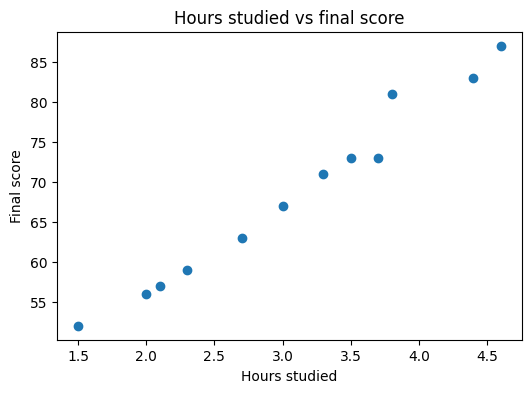

In [6]:
plt.figure(figsize=(6, 4))
plt.scatter(df["hours_studied"], df["final_score"])
plt.xlabel("Hours studied")
plt.ylabel("Final score")
plt.title("Hours studied vs final score")
plt.show()

### Your turn 1: Quick explanation

Answer in one sentence:

- Which feature has the strongest correlation with `final_score`?
- What does the standard deviation of `final_score` tell us?
- Why can the mode be different from the mean?

## 2. Abstract Base Classes: define the model contract

**Math mode**

\[
\texttt{fit}(X, y) \rightarrow \text{learned information}
\]

\[
\texttt{predict}(X_{new}) \rightarrow \hat{y}
\]

**CS interpretation**

A `BaseModel` abstract base class is a contract. Every child model must provide `fit` and `predict`.

In [7]:
class BaseModel(ABC):
    """Contract for every model in this small AI-model framework."""

    @abstractmethod
    def fit(self, X, y):
        """Learn model parameters from training data."""
        raise NotImplementedError

    @abstractmethod
    def predict(self, X):
        """Return one prediction for each row of X."""
        raise NotImplementedError

### Code-supported hint: incomplete child classes cannot be used
A child class that inherits from `BaseModel` must implement both `fit` and `predict`. The `try/except` block below catches the error so you can read it without stopping the notebook.

In [8]:
class BrokenModel(BaseModel):
    def fit(self, X, y):
        return self
    # predict is missing on purpose

try:
    bad_model = BrokenModel()
except TypeError as err:
    print("Python stops us:")
    print(err)

Python stops us:
Can't instantiate abstract class BrokenModel without an implementation for abstract method 'predict'


### Your turn 2: Contract check

Why did `BrokenModel()` fail? Which method is missing?

## 3. Concrete model 1: mean baseline

**Statistics equation**

\[
\hat{y}_{baseline} = \bar{y}_{train}
\]

**Interpretation**

The baseline predicts the same average training value for every test row. A stronger model should beat this simple baseline.

In [9]:
class MeanBaselineModel(BaseModel):
    def __init__(self):
        self.mean_ = None

    def fit(self, X, y):
        self.mean_ = float(pd.Series(y).mean())
        return self

    def predict(self, X):
        if self.mean_ is None:
            raise RuntimeError("Call fit before predict.")
        return np.full(len(X), self.mean_, dtype=float)

In [10]:
features = ["hours_studied", "quiz_average"]
target = "final_score"

train_df = df.iloc[:8].copy()
test_df = df.iloc[8:].copy()

baseline = MeanBaselineModel()
baseline.fit(train_df[features], train_df[target])
baseline_predictions = baseline.predict(test_df[features])
print("Baseline predictions:", baseline_predictions)

Baseline predictions: [65.25 65.25 65.25 65.25]


### Your turn 3: Practice coding task

Write a `MedianBaselineModel`. It should store the median of `y_train` and predict that value for every test row.

Use the empty cell below for learner work. The next cell gives one possible solution.

In [11]:
# Your work cell.
# class MedianBaselineModel(BaseModel):
#     ...
print("Write MedianBaselineModel here, then compare it to MeanBaselineModel.")

Write MedianBaselineModel here, then compare it to MeanBaselineModel.


In [12]:
class MedianBaselineModel(BaseModel):
    def __init__(self):
        self.median_ = None

    def fit(self, X, y):
        self.median_ = float(pd.Series(y).median())
        return self

    def predict(self, X):
        if self.median_ is None:
            raise RuntimeError("Call fit before predict.")
        return np.full(len(X), self.median_, dtype=float)

## 4. Concrete model 2: closed-form linear regression

**Math mode**

\[
\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x_1 + \hat{\beta}_2 x_2
\]

Matrix form:

\[
\hat{y} = X\hat{\beta}
\]

Closed-form least-squares estimate:

\[
\hat{\beta} = (X^T X)^{-1}X^T y
\]

**Remark**

We use `np.linalg.pinv` instead of a plain inverse to make the example more numerically robust for small teaching datasets.

In [13]:
class ClosedFormLinearRegressionModel(BaseModel):
    def __init__(self, feature_names):
        self.feature_names = feature_names
        self.beta_ = None

    def _design_matrix(self, X):
        X_values = X[self.feature_names].to_numpy(dtype=float)
        return np.column_stack([np.ones(len(X_values)), X_values])

    def fit(self, X, y):
        X_design = self._design_matrix(X)
        y_values = pd.Series(y).to_numpy(dtype=float)
        self.beta_ = np.linalg.pinv(X_design.T @ X_design) @ X_design.T @ y_values
        return self

    def predict(self, X):
        if self.beta_ is None:
            raise RuntimeError("Call fit before predict.")
        return self._design_matrix(X) @ self.beta_

In [14]:
ols = ClosedFormLinearRegressionModel(feature_names=features)
ols.fit(train_df[features], train_df[target])
ols_predictions = ols.predict(test_df[features])

print("beta =", np.round(ols.beta_, 3))
print("predictions =", np.round(ols_predictions, 2))

beta = [6.55  1.637 0.903]
predictions = [56.04 75.81 84.18 87.22]


### Your turn 4: Interpret coefficients

In the coefficient vector `[6.550, 1.637, 0.903]`:

- Which number is the intercept?
- Which number is attached to `hours_studied`?
- Which number is attached to `quiz_average`?

## 5. Evaluate models with the same function

**Metrics**

\[
MAE = \frac{1}{n}\sum_i |y_i - \hat{y}_i|
\]

\[
RMSE = \sqrt{\frac{1}{n}\sum_i (y_i - \hat{y}_i)^2}
\]

\[
R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
\]

In [15]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    denominator = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / denominator if denominator != 0 else np.nan
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

def evaluate_model(model, train_df, test_df, features, target):
    model.fit(train_df[features], train_df[target])
    preds = model.predict(test_df[features])
    output = regression_metrics(test_df[target], preds)
    output["model"] = model.__class__.__name__
    return output, preds

models = [
    MeanBaselineModel(),
    MedianBaselineModel(),
    ClosedFormLinearRegressionModel(feature_names=features),
]

rows = []
predictions = {}
for model in models:
    row, preds = evaluate_model(model, train_df, test_df, features, target)
    rows.append(row)
    predictions[row["model"]] = preds

results = pd.DataFrame(rows).set_index("model")
display(results)

,MAE,RMSE,R2
model,,,
MeanBaselineModel,13.875000,15.134811,-0.709422
MedianBaselineModel,14.000000,15.297059,-0.746269
ClosedFormLinearRegressionModel,1.295281,1.604506,0.980788


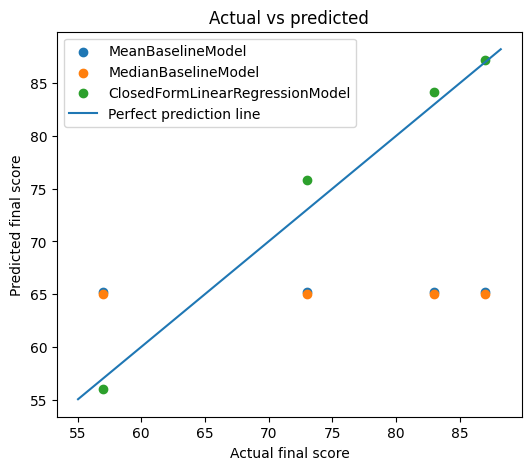

In [16]:
plt.figure(figsize=(6, 5))
y_test = test_df[target].to_numpy(float)
for name, preds in predictions.items():
    plt.scatter(y_test, preds, label=name)
low = min(y_test.min(), *(p.min() for p in predictions.values())) - 1
high = max(y_test.max(), *(p.max() for p in predictions.values())) + 1
plt.plot([low, high], [low, high], label="Perfect prediction line")
plt.xlabel("Actual final score")
plt.ylabel("Predicted final score")
plt.title("Actual vs predicted")
plt.legend()
plt.show()

### Your turn 5: Model comparison

Which model has the lowest MAE? Explain the answer without using code words.

## 6. Robust logging and data validation with a decorator

**Core idea**

A decorator wraps a function. Here, the wrapper logs the method call, validates the data, runs the original method, logs the duration, and returns the result.

This keeps the model math clean.

### Code-supported hint: check selected features before fitting
Before a model trusts `X`, check whether the selected columns exist and whether they contain missing values.

In [17]:
features = ["hours_studied", "quiz_average"]
print("Selected feature columns:", features)
print("Columns in df:", df.columns.tolist())
print("Missing values in selected features:")
print(df[features].isna().sum())

if df[features].isna().any().any():
    print("Fix missing values before modeling.")
else:
    print("Selected features have no missing values.")

Selected feature columns: ['hours_studied', 'quiz_average']
Columns in df: ['student_id', 'hours_studied', 'attendance_rate', 'assignments_submitted', 'quiz_average', 'final_score']
Missing values in selected features:
hours_studied    0
quiz_average     0
dtype: int64
Selected features have no missing values.


In [18]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True,
)
logger = logging.getLogger("lab2")

class DataValidationError(ValueError):
    """Raised when model input data fails a validation check."""

def validate_X(X, required_columns=None):
    if not isinstance(X, pd.DataFrame):
        raise DataValidationError("X must be a pandas DataFrame.")
    if X.empty:
        raise DataValidationError("X must not be empty.")

    required_columns = required_columns or list(X.columns)
    missing = [col for col in required_columns if col not in X.columns]
    if missing:
        raise DataValidationError(f"X is missing required columns: {missing}")

    if X[required_columns].isna().any().any():
        raise DataValidationError("X contains missing values.")

def validate_fit_data(X, y, required_columns=None):
    validate_X(X, required_columns)
    if y is None:
        raise DataValidationError("y must not be None.")
    if len(y) != len(X):
        raise DataValidationError("X and y must have the same number of rows.")
    if pd.Series(y).isna().any():
        raise DataValidationError("y contains missing values.")

def log_execution(func):
    @functools.wraps(func)
    def wrapper(self, *args, **kwargs):
        method_name = func.__name__
        model_name = self.__class__.__name__
        start = time.perf_counter()

        X = args[0] if len(args) >= 1 else kwargs.get("X")
        y = args[1] if len(args) >= 2 else kwargs.get("y")
        rows = len(X) if hasattr(X, "__len__") else "unknown"

        logger.info(f"START {model_name}.{method_name} rows={rows}")
        try:
            required_columns = getattr(self, "feature_names", None)
            if method_name == "fit":
                validate_fit_data(X, y, required_columns)
            elif method_name == "predict":
                validate_X(X, required_columns)

            result = func(self, *args, **kwargs)
            duration = time.perf_counter() - start
            logger.info(f"END {model_name}.{method_name} duration={duration:.4f}s")
            return result
        except Exception as exc:
            logger.error(f"FAIL {model_name}.{method_name} error={exc}")
            raise

    return wrapper

In [19]:
class LoggedClosedFormLinearRegressionModel(ClosedFormLinearRegressionModel):
    @log_execution
    def fit(self, X, y):
        return super().fit(X, y)

    @log_execution
    def predict(self, X):
        return super().predict(X)

logged_ols = LoggedClosedFormLinearRegressionModel(feature_names=features)
logged_ols.fit(train_df[features], train_df[target])
logged_predictions = logged_ols.predict(test_df[features])
print(np.round(logged_predictions, 2))

2026-05-04 10:28:13,727 - INFO - START LoggedClosedFormLinearRegressionModel.fit rows=8
2026-05-04 10:28:13,731 - INFO - END LoggedClosedFormLinearRegressionModel.fit duration=0.0042s
2026-05-04 10:28:13,733 - INFO - START LoggedClosedFormLinearRegressionModel.predict rows=4
2026-05-04 10:28:13,737 - INFO - END LoggedClosedFormLinearRegressionModel.predict duration=0.0035s


[56.04 75.81 84.18 87.22]


In [20]:
# Same math check: logged model and plain model should match.
print("Same predictions?", np.allclose(logged_predictions, ols_predictions))

Same predictions? True


### Your turn 6: Read the logs

Find one `START` log line and one `END` log line. What information did the log provide?

## 7. Validation errors: break the input on purpose

A robust system should fail early with a clear error message.

In [21]:
# Example 1: missing feature column
try:
    bad_X = train_df[["hours_studied"]]  # quiz_average is missing
    logged_ols.fit(bad_X, train_df[target])
except Exception as exc:
    print("Caught validation error:", exc)

# Example 2: missing value
try:
    bad_X = train_df[features].copy()
    bad_X.loc[0, "quiz_average"] = np.nan
    logged_ols.fit(bad_X, train_df[target])
except Exception as exc:
    print("Caught validation error:", exc)

2026-05-04 10:28:13,758 - INFO - START LoggedClosedFormLinearRegressionModel.fit rows=8
2026-05-04 10:28:13,761 - ERROR - FAIL LoggedClosedFormLinearRegressionModel.fit error=X is missing required columns: ['quiz_average']
2026-05-04 10:28:13,767 - INFO - START LoggedClosedFormLinearRegressionModel.fit rows=8
2026-05-04 10:28:13,776 - ERROR - FAIL LoggedClosedFormLinearRegressionModel.fit error=X contains missing values.


Caught validation error: X is missing required columns: ['quiz_average']
Caught validation error: X contains missing values.


### Your turn 7: Create your own validation test

Choose one:

- Pass a list instead of a DataFrame.
- Make `y` shorter than `X`.
- Insert a missing value in `hours_studied`.
- Use an empty DataFrame.

In [22]:
# Your validation experiment cell.
print("Create one bad input here and catch the error with try/except.")

Create one bad input here and catch the error with try/except.


## 8. Optional dataset rotation

The same interface works for other small datasets. Each group can choose one dataset and reuse the same model classes.

In [23]:
DATASET_REGISTRY = {
    "student_scores": {
        "file": "AKHU_student_scores_lab2.csv",
        "features": ["hours_studied", "quiz_average"],
        "target": "final_score",
        "question": "Can study hours and quiz average predict final score?",
    },
    "sleep_focus": {
        "file": "AKHU_sleep_screen_focus_lab2.csv",
        "features": ["sleep_hours", "screen_time_hours", "exercise_minutes"],
        "target": "focus_score",
        "question": "Can sleep, screen time, and exercise predict focus score?",
    },
    "campus_energy": {
        "file": "AKHU_campus_energy_lab2.csv",
        "features": ["hour", "temperature_c", "students_on_campus"],
        "target": "electricity_kwh",
        "question": "Can time, temperature, and campus activity predict electricity use?",
    },
    "chatbot_logs": {
        "file": "AKHU_ai_chatbot_logs_lab2.csv",
        "features": ["prompt_length_words", "tokens_used", "had_error"],
        "target": "response_time_sec",
        "question": "Can prompt size and errors predict response time?",
    },
}

pd.DataFrame(DATASET_REGISTRY).T

,file,features,target,question
student_scores,AKHU_student_scores_lab2.csv,"[hours_studied, quiz_average]",final_score,Can study hours and quiz average predict final...
sleep_focus,AKHU_sleep_screen_focus_lab2.csv,"[sleep_hours, screen_time_hours, exercise_minu...",focus_score,"Can sleep, screen time, and exercise predict f..."
campus_energy,AKHU_campus_energy_lab2.csv,"[hour, temperature_c, students_on_campus]",electricity_kwh,"Can time, temperature, and campus activity pre..."
chatbot_logs,AKHU_ai_chatbot_logs_lab2.csv,"[prompt_length_words, tokens_used, had_error]",response_time_sec,Can prompt size and errors predict response time?


In [24]:
def run_dataset_demo(dataset_key):
    spec = DATASET_REGISTRY[dataset_key]
    frame = pd.read_csv(DATA_DIR / spec["file"])
    split = int(len(frame) * 0.7)
    train_frame = frame.iloc[:split].copy()
    test_frame = frame.iloc[split:].copy()
    model = LoggedClosedFormLinearRegressionModel(feature_names=spec["features"])
    row, preds = evaluate_model(model, train_frame, test_frame, spec["features"], spec["target"])
    print(spec["question"])
    print("features:", spec["features"])
    print("target:", spec["target"])
    display(pd.DataFrame([row]).set_index("model"))
    return frame, preds

frame, preds = run_dataset_demo("sleep_focus")

2026-05-04 10:28:13,878 - INFO - START LoggedClosedFormLinearRegressionModel.fit rows=14
2026-05-04 10:28:13,886 - INFO - END LoggedClosedFormLinearRegressionModel.fit duration=0.0075s
2026-05-04 10:28:13,889 - INFO - START LoggedClosedFormLinearRegressionModel.predict rows=6
2026-05-04 10:28:13,895 - INFO - END LoggedClosedFormLinearRegressionModel.predict duration=0.0052s


Can sleep, screen time, and exercise predict focus score?
features: ['sleep_hours', 'screen_time_hours', 'exercise_minutes']
target: focus_score


,MAE,RMSE,R2
model,,,
LoggedClosedFormLinearRegressionModel,4.929208,5.453296,0.771808


### Your turn 8: Dataset rotation task

Change `"sleep_focus"` to `"campus_energy"` or `"chatbot_logs"`. Then answer:

1. What are the features?
2. What is the target?
3. Did the logged model run successfully?
4. Which validation error could happen for this dataset?

## 8A. Code-supported hints for common mistakes
Use these short cells when you are stuck. Each cell checks one common issue before the model becomes more complicated.

In [25]:
# Hint 1: identify columns before choosing X and y
print(df.shape)
print(df.columns.tolist())
print(df.head())

(12, 6)
['student_id', 'hours_studied', 'attendance_rate', 'assignments_submitted', 'quiz_average', 'final_score']
  student_id  hours_studied  attendance_rate  assignments_submitted  \
0        S01            1.5             0.55                      4   
1        S02            2.0             0.60                      5   
2        S03            2.3             0.66                      5   
3        S04            2.7             0.70                      6   
4        S05            3.0             0.74                      7   

   quiz_average  final_score  
0            48           52  
1            50           56  
2            54           59  
3            58           63  
4            62           67  


In [26]:
# Hint 2: choose features and target explicitly
features = ["hours_studied", "quiz_average"]
target = "final_score"
X = df[features]
y = df[target]
print(X.head())
print(y.head())

   hours_studied  quiz_average
0            1.5            48
1            2.0            50
2            2.3            54
3            2.7            58
4            3.0            62
0    52
1    56
2    59
3    63
4    67
Name: final_score, dtype: int64


In [27]:
# Hint 3: fit before predict
model = MeanBaselineModel()
model.fit(train_df[features], train_df[target])
preds = model.predict(test_df[features])
print(preds)

[65.25 65.25 65.25 65.25]


In [28]:
# Hint 4: create a validation error on purpose and read it
bad_X = test_df[features].drop(columns=["quiz_average"])
try:
    logged_ols.predict(bad_X)
except Exception as err:
    print(type(err).__name__)
    print(err)

2026-05-04 10:28:13,998 - INFO - START LoggedClosedFormLinearRegressionModel.predict rows=4
2026-05-04 10:28:14,001 - ERROR - FAIL LoggedClosedFormLinearRegressionModel.predict error=X is missing required columns: ['quiz_average']


DataValidationError
X is missing required columns: ['quiz_average']


## 9. Exit ticket

Write three sentences:

1. A `BaseModel` is useful because ...
2. A decorator is useful because ...
3. One metric I can interpret is ...